In [1]:
import sys
from pathlib import Path

BASE = Path("/share/home/e2406751/Superresolution-TIR")
sys.path.insert(0, str(BASE))

In [2]:
import torch
from torch.utils.data import DataLoader
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
from scripts.utils.dataset import SRDataset
from scripts.models.realesrgan import RealESRGANModule

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load model ──────────────────────────────────────────────
MODEL_PATH = str(BASE / "checkpoints/gan_final/exp2_fixed_lr_schedule_epoch=56_val_water_mae=0.8773.ckpt") # spade 

model = RealESRGANModule.load_from_checkpoint(MODEL_PATH, strict=True).to(device).eval()
for p in model.parameters():
    p.requires_grad_(False)


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/share/home/e2406751/Superresoluti

[INFO] generator loaded 702 params
[INFO] discriminator loaded 28 params


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_

In [3]:
import json

PATCHES_DIR   = BASE / "data/processed/patches"
STATS_PATH    = PATCHES_DIR / "stats.json"
METADATA_PATH = PATCHES_DIR / "metadata.json"


with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN    = stats_data["hr"]["mean"]
HR_STD     = stats_data["hr"]["std"]
LR_MEAN    = stats_data["lr"]["mean"]
LR_STD     = stats_data["lr"]["std"]
DATA_RANGE = stats_data["hr_data_range"]
DATA_MIN   = stats_data["hr_percentiles"]["p1"]


In [4]:
# ── Datasets ────────────────────────────────────────────────
train_ds = SRDataset(split="train", patches_dir=PATCHES_DIR, stats_path=STATS_PATH,
                      use_aux=True, use_water_mask=True,
                      aux_dir=str(PATCHES_DIR / "train" / "AUX"), transform=None)  # no augmentation for baseline
test_ds  = SRDataset(split="test", patches_dir=PATCHES_DIR, stats_path=STATS_PATH,
                      use_aux=True, use_water_mask=True,
                      aux_dir=str(PATCHES_DIR / "test" / "AUX"), transform=None)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)


mean convergence delta (°C): 0.0947117879986763


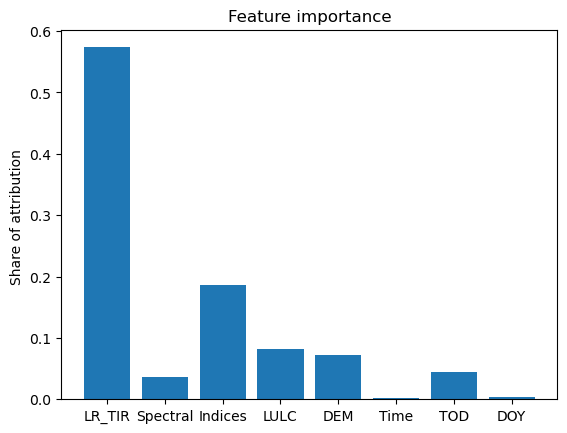

In [ ]:
## MEAN OF GROUPS
# ── Step 1: baseline from TRAIN set (x = lr + aux_lr + time_channels, 27ch @ 64px) ──
ch_sum, n_pixels = torch.zeros(27), 0
for batch in train_loader:
    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1)  # [B,27,64,64]
    ch_sum += x.sum(dim=(0, 2, 3))
    n_pixels += x.shape[0] * x.shape[2] * x.shape[3]
channel_means = (ch_sum / n_pixels).view(1, 27, 1, 1)
torch.save(channel_means, "ig_baseline_channel_means.pt")

# ── Step 2: wrapper that mirrors forward() but takes x as a plain tensor ──
CHANNEL_GROUPS = {
    "LR_TIR":   [0],
    "Spectral": list(range(1, 6)),
    "Indices":  list(range(6, 9)),
    "LULC":     list(range(9, 23)),
    "DEM":      [23],
    "TOD":      [24],
    "DOY":      [25],
}

def make_wrapper(seg_mid, seg_hr, valid_mask):
    def wrapper(x):
        gen_out = model.net_g(x, seg_mid, seg_hr) if model.use_spade else model.net_g(x, None, None)
        sr = model.out_head(gen_out)                       # [B,1,256,256], normalized (z-score) space
        sr_phys = model.denormalize(sr)                     # -> physical °C, for interpretable attribution units
        return (sr_phys * valid_mask).sum(dim=(1,2,3)) / valid_mask.sum(dim=(1,2,3)).clamp(min=1)
    return wrapper

ig = IntegratedGradients(make_wrapper(None, None, None))  # placeholder, rebuilt per-batch below

# ── Step 3: attribution loop over TEST set ──
channel_importance_total = torch.zeros(27)
deltas = []

for batch in test_loader:
    batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1).float()
    x.requires_grad_(True)

    seg_mid = batch["aux_mid"][:, 8:22].float() if model.use_spade else None
    seg_hr  = batch["aux_hr"][:, 8:22].float()  if model.use_spade else None
    valid_mask = batch["hr_mask"][:, 0:1].float()   # excludes NaN/nodata; swap to water_mask later for a water-only pass

    ig_batch = IntegratedGradients(make_wrapper(seg_mid, seg_hr, valid_mask))
    baseline_x = channel_means.expand_as(x).to(device)

    attr, delta = ig_batch.attribute(
        x,
        baselines=baseline_x,
        n_steps=30,
        internal_batch_size=1,
        return_convergence_delta=True,
    )
    channel_importance_total += attr.abs().mean(dim=(0,2,3)).detach().cpu()
    deltas.append(delta.abs().mean().item())

print("mean convergence delta (°C):", sum(deltas)/len(deltas))

channel_importance = channel_importance_total
group_importance = {
    g: channel_importance[idxs].mean().item()
    for g, idxs in CHANNEL_GROUPS.items()
}
total = sum(group_importance.values())
group_share = {g: v/total for g, v in group_importance.items()}

plt.bar(group_share.keys(), group_share.values())
plt.ylabel("Share of attribution ")
plt.title(f"Feature importance")
plt.show()

mean convergence delta (°C): 0.0998527929186821


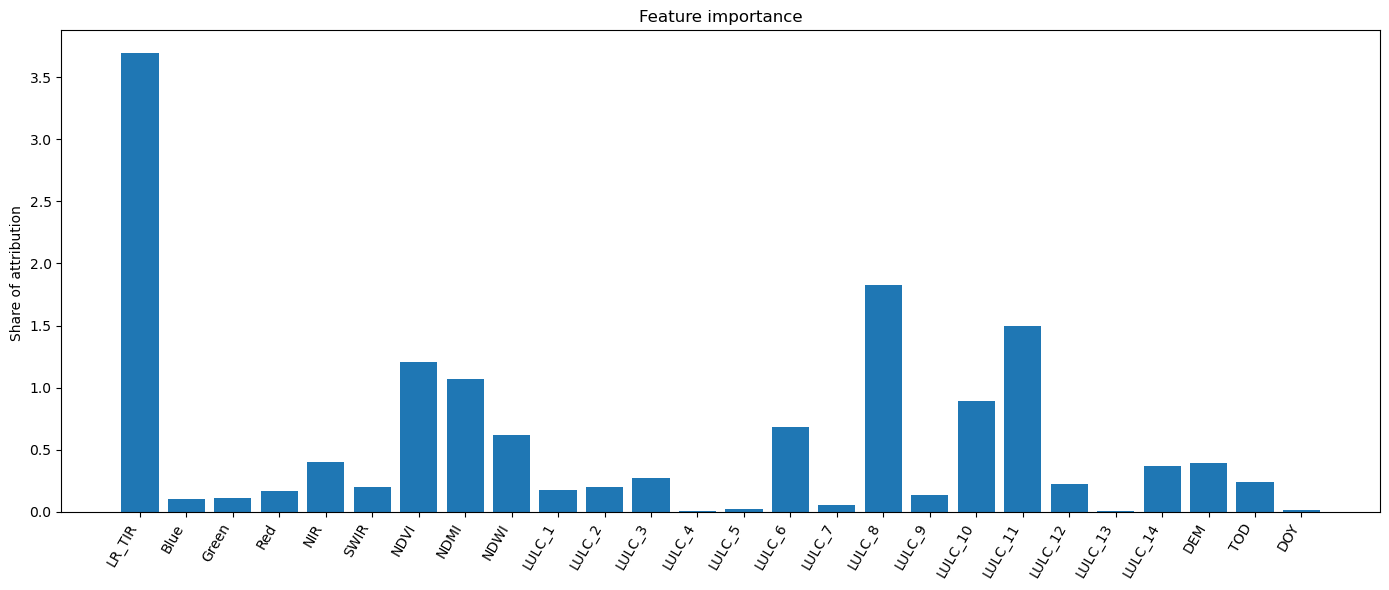

In [10]:
## EACH CHANNEL
import numpy as np
# ── Step 1: baseline from TRAIN set (x = lr + aux_lr + time_channels, 26ch @ 64px) ──
ch_sum, n_pixels = torch.zeros(26), 0
for batch in train_loader:
    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1)  # [B,26,64,64]
    ch_sum += x.sum(dim=(0, 2, 3))
    n_pixels += x.shape[0] * x.shape[2] * x.shape[3]
channel_means = (ch_sum / n_pixels).view(1, 26, 1, 1)
torch.save(channel_means, "ig_baseline_channel_means.pt")

# ── Step 2: wrapper that mirrors forward() but takes x as a plain tensor ──
CHANNEL_GROUPS = {
    "LR_TIR":   [0],
    "Spectral": list(range(1, 6)),
    "Indices":  list(range(6, 9)),
    "LULC":     list(range(9, 23)),
    "DEM":      [23],
    "TOD":      [24],
    "DOY":      [25],
}

def make_wrapper(seg_mid, seg_hr, valid_mask):
    def wrapper(x):
        gen_out = model.net_g(x, seg_mid, seg_hr) if model.use_spade else model.net_g(x, None, None)
        sr = model.out_head(gen_out)                       # [B,1,256,256], normalized (z-score) space
        sr_phys = model.denormalize(sr)                     # -> physical °C, for interpretable attribution units
        return (sr_phys * valid_mask).sum(dim=(1,2,3)) / valid_mask.sum(dim=(1,2,3)).clamp(min=1)
    return wrapper

ig = IntegratedGradients(make_wrapper(None, None, None))  # placeholder, rebuilt per-batch below

# ── Step 3: attribution loop over TEST set ──
channel_importance_total = torch.zeros(26)
deltas = []

for batch in test_loader:
    batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1).float()
    x.requires_grad_(True)

    seg_mid = batch["aux_mid"][:, 8:22].float() if model.use_spade else None
    seg_hr  = batch["aux_hr"][:, 8:22].float()  if model.use_spade else None
    valid_mask = batch["hr_mask"][:, 0:1].float()   # excludes NaN/nodata; swap to water_mask later for a water-only pass

    ig_batch = IntegratedGradients(make_wrapper(seg_mid, seg_hr, valid_mask))
    baseline_x = channel_means.expand_as(x).to(device)

    attr, delta = ig_batch.attribute(
        x,
        baselines=baseline_x,
        n_steps=30,
        internal_batch_size=1,
        return_convergence_delta=True,
    )
    channel_importance_total += attr.abs().mean(dim=(0,2,3)).detach().cpu()
    deltas.append(delta.abs().mean().item())

print("mean convergence delta (°C):", sum(deltas)/len(deltas))

channel_importance = channel_importance_total.detach().cpu().numpy()

channel_names = [
    "LR_TIR",
    "Blue", "Green", "Red", "NIR", "SWIR",
    "NDVI", "NDMI", "NDWI",
    "LULC_1", "LULC_2", "LULC_3", "LULC_4",
    "LULC_5", "LULC_6", "LULC_7", "LULC_8",
    "LULC_9", "LULC_10", "LULC_11", "LULC_12",
    "LULC_13", "LULC_14",
    "DEM",
    "TOD", "DOY"
]

plt.figure(figsize=(14,6))
plt.bar(range(len(channel_importance)), channel_importance)

plt.xticks(
    range(len(channel_importance)),
    channel_names,
    rotation=60,
    ha="right"
)

plt.ylabel("Share of attribution ")
plt.title(f"Feature importance")
plt.tight_layout()
plt.show()

Calculating baseline distributions...


Running attributions...


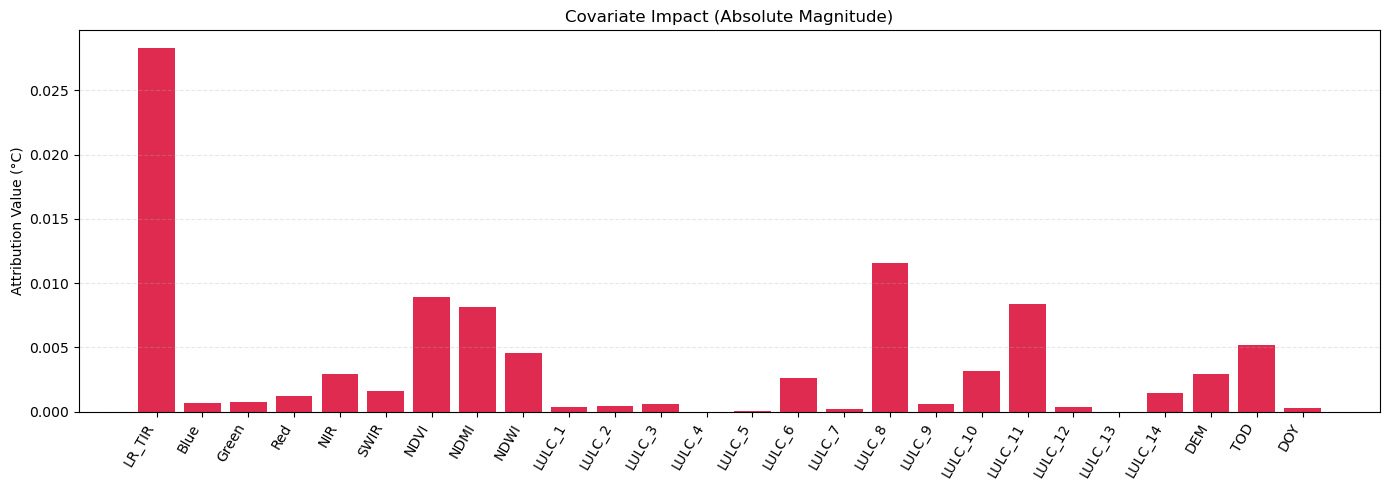

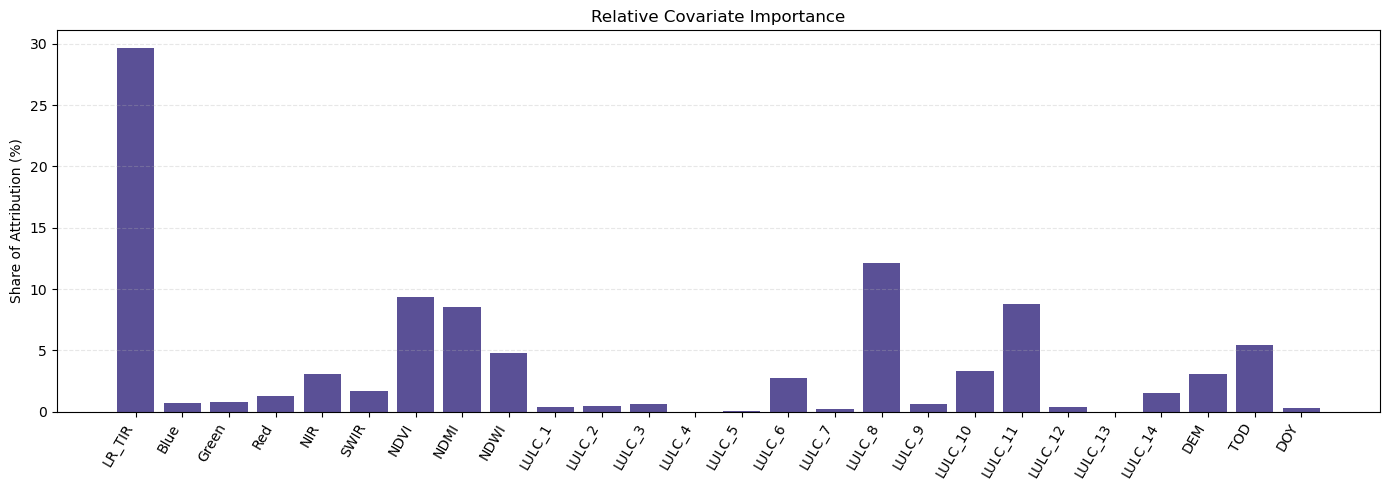

In [11]:
# ── Step 1: Hybrid Mathematically Sound Baseline ───────────
print("Calculating baseline distributions...")
ch_sum, n_pixels = torch.zeros(26), 0
for batch in train_loader:
    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1)
    ch_sum += x.sum(dim=(0, 2, 3))
    n_pixels += x.shape[0] * x.shape[2] * x.shape[3]
global_means = (ch_sum / n_pixels).view(1, 26, 1, 1)

# Construct an intelligent baseline tensor
baseline_channel_means = torch.zeros(1, 26, 1, 1)
# Continuous variables: Use spatial mean reference
continuous_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 23] # LR_TIR, Spectral, Indices, DEM
baseline_channel_means[:, continuous_indices] = global_means[:, continuous_indices]
# Categorical/Discrete variables (LULC, Time metadata): Keep at 0 (absence of indicator)

torch.save(baseline_channel_means, "ig_baseline_hybrid.pt")
baseline_channel_means = baseline_channel_means.to(device)

# ── Step 2: Dynamic Captum Wrapper ──────────────────────────
# Captum expects a function signature that takes only the tensor being attributed as input.
class WrappedModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.seg_mid = None
        self.seg_hr = None
        self.valid_mask = None

    def set_batch_metadata(self, seg_mid, seg_hr, valid_mask):
        self.seg_mid = seg_mid
        self.seg_hr = seg_hr
        self.valid_mask = valid_mask

    def forward(self, x):
        gen_out = self.model.net_g(x, self.seg_mid, self.seg_hr) if self.model.use_spade else self.model.net_g(x, None, None)
        sr = self.model.out_head(gen_out)
        sr_phys = self.model.denormalize(sr) 
        
        # Guard against zero-element masks
        mask_sum = self.valid_mask.sum(dim=(1, 2, 3)).clamp(min=1)
        return (sr_phys * self.valid_mask).sum(dim=(1, 2, 3)) / mask_sum

wrapped_model = WrappedModel(model)
ig = IntegratedGradients(wrapped_model)

# ── Inside Step 3: Run Attributions and Average ─────────────────
channel_importance_total = torch.zeros(26)
deltas = []

print("Running attributions...")
for batch in test_loader:
    batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1).float()
    x.requires_grad_(True)

    seg_mid = batch["aux_mid"][:, 8:22].float() if model.use_spade else None
    seg_hr  = batch["aux_hr"][:, 8:22].float()  if model.use_spade else None
    valid_mask = batch["hr_mask"][:, 0:1].float() 

    wrapped_model.set_batch_metadata(seg_mid, seg_hr, valid_mask)
    baseline_x = baseline_channel_means.expand_as(x)

    attr, delta = ig.attribute(
        x,
        baselines=baseline_x,
        n_steps=50,
        internal_batch_size=1,
        return_convergence_delta=True,
    )
    
    # Track the absolute magnitude of change forced by each covariate
    channel_importance_total += attr.abs().mean(dim=(0, 2, 3)).detach().cpu()
    deltas.append(delta.abs().mean().item())

# Calculate the mean absolute physical impact across all test samples
mean_physical_importance = channel_importance_total.numpy() / len(test_loader)

# Calculate the normalized percentage share of attribution
total_physical_sum = np.sum(mean_physical_importance)
# Guard against division by zero just in case
share_of_attribution = (mean_physical_importance / (total_physical_sum if total_physical_sum > 0 else 1)) * 100


channel_names = [
    "LR_TIR",
    "Blue", "Green", "Red", "NIR", "SWIR",
    "NDVI", "NDMI", "NDWI",
    "LULC_1", "LULC_2", "LULC_3", "LULC_4",
    "LULC_5", "LULC_6", "LULC_7", "LULC_8",
    "LULC_9", "LULC_10", "LULC_11", "LULC_12",
    "LULC_13", "LULC_14",
    "DEM",
    "TOD", "DOY"
]

indices = np.arange(len(channel_names))

# ── Plot 1: Physical Scale (°C) ─────────────────────────────
plt.figure(figsize=(14, 5))
plt.bar(indices, mean_physical_importance, color="crimson", alpha=0.9)
plt.xticks(indices, channel_names, rotation=60, ha="right")
plt.ylabel("Attribution Value (°C)")
plt.title("Covariate Impact (Absolute Magnitude)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# ── Plot 2: Relative Scale (% Share) ─────────────────────────
plt.figure(figsize=(14, 5))
plt.bar(indices, share_of_attribution, color="darkslateblue", alpha=0.9)
plt.xticks(indices, channel_names, rotation=60, ha="right")
plt.ylabel("Share of Attribution (%)")
plt.title("Relative Covariate Importance")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Calculating baseline distributions...
Running attributions...
--> Generating spatial attribution maps for all 26 channels...


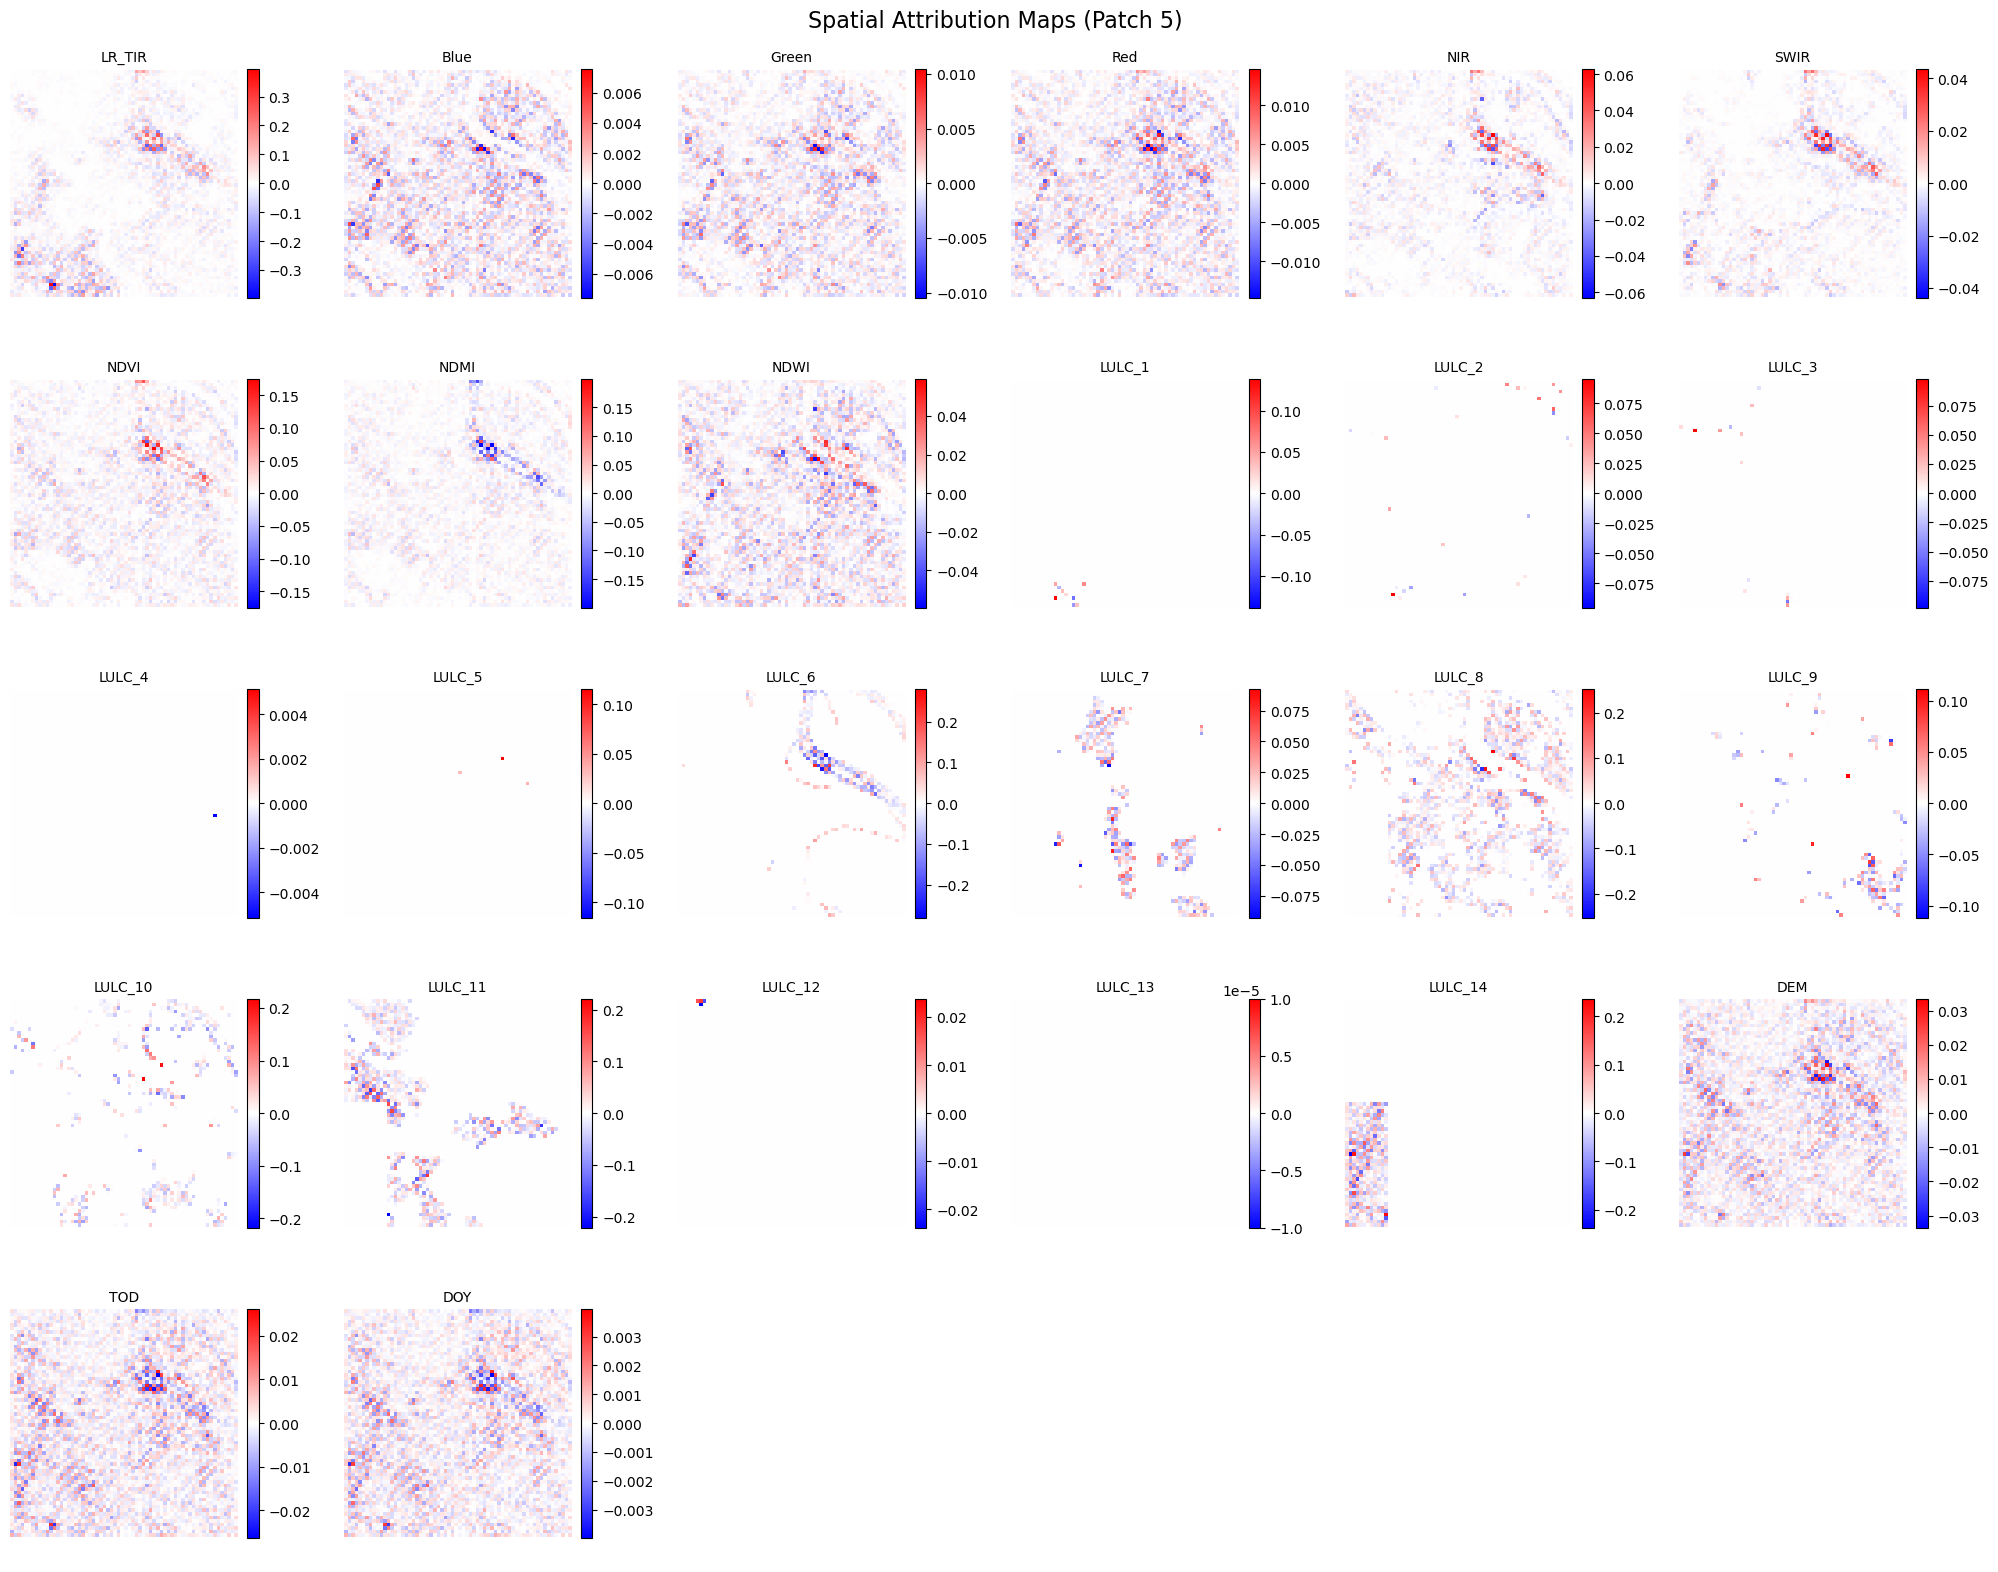

--> Generating spatial attribution maps for all 26 channels...


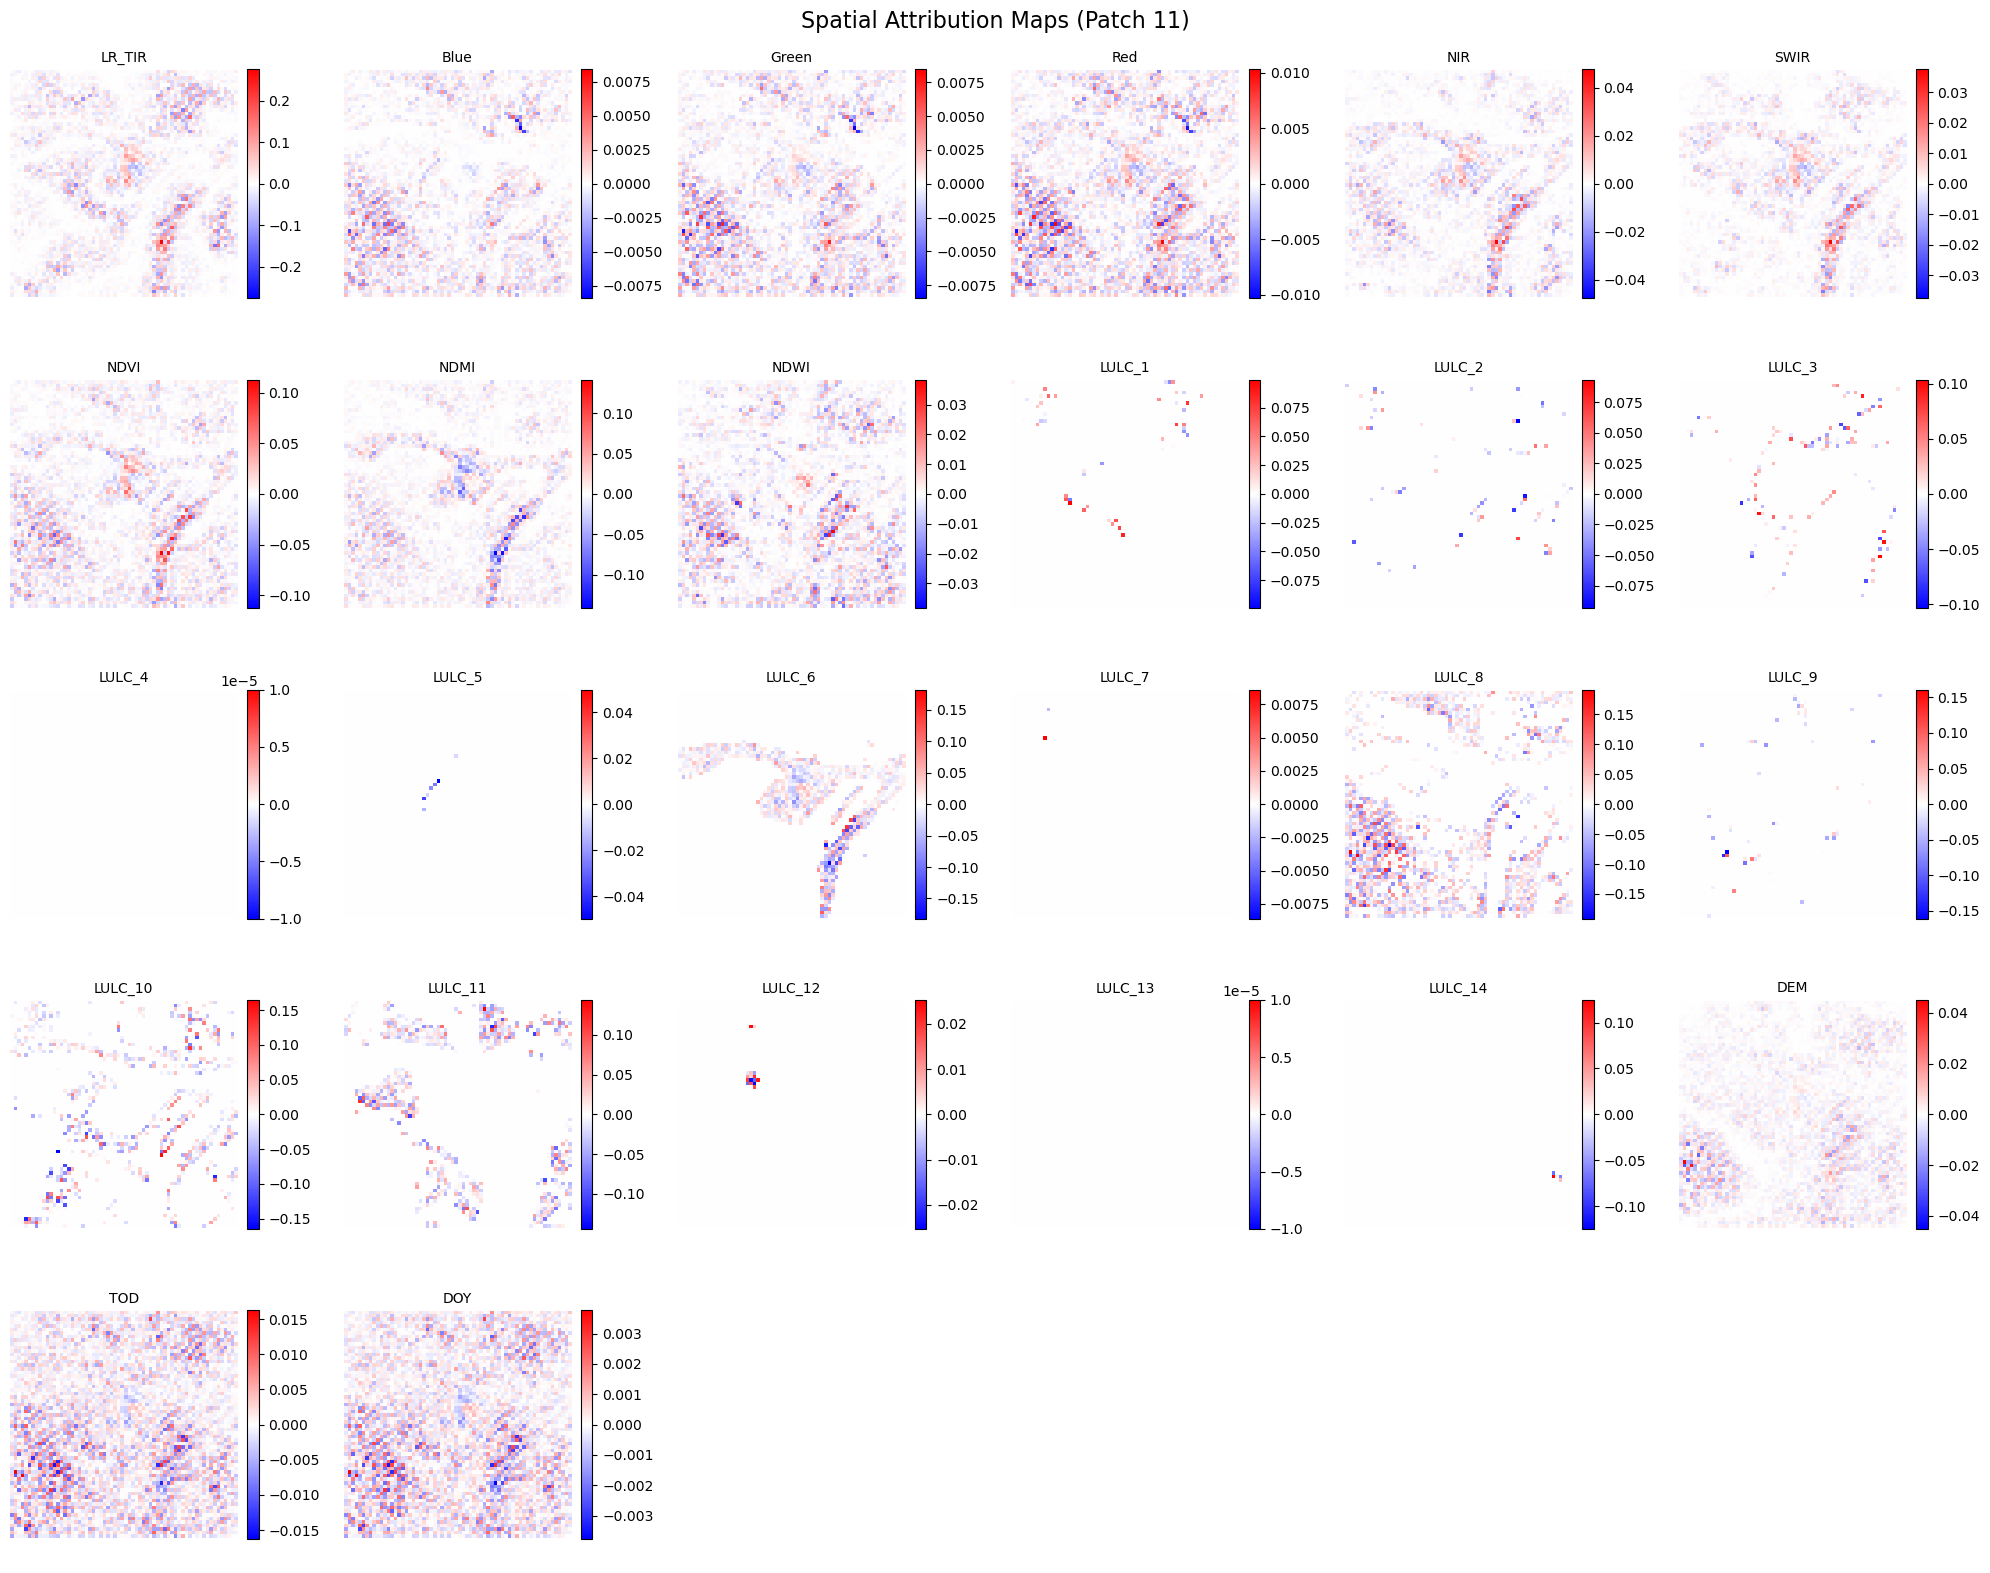

--> Generating spatial attribution maps for all 26 channels...


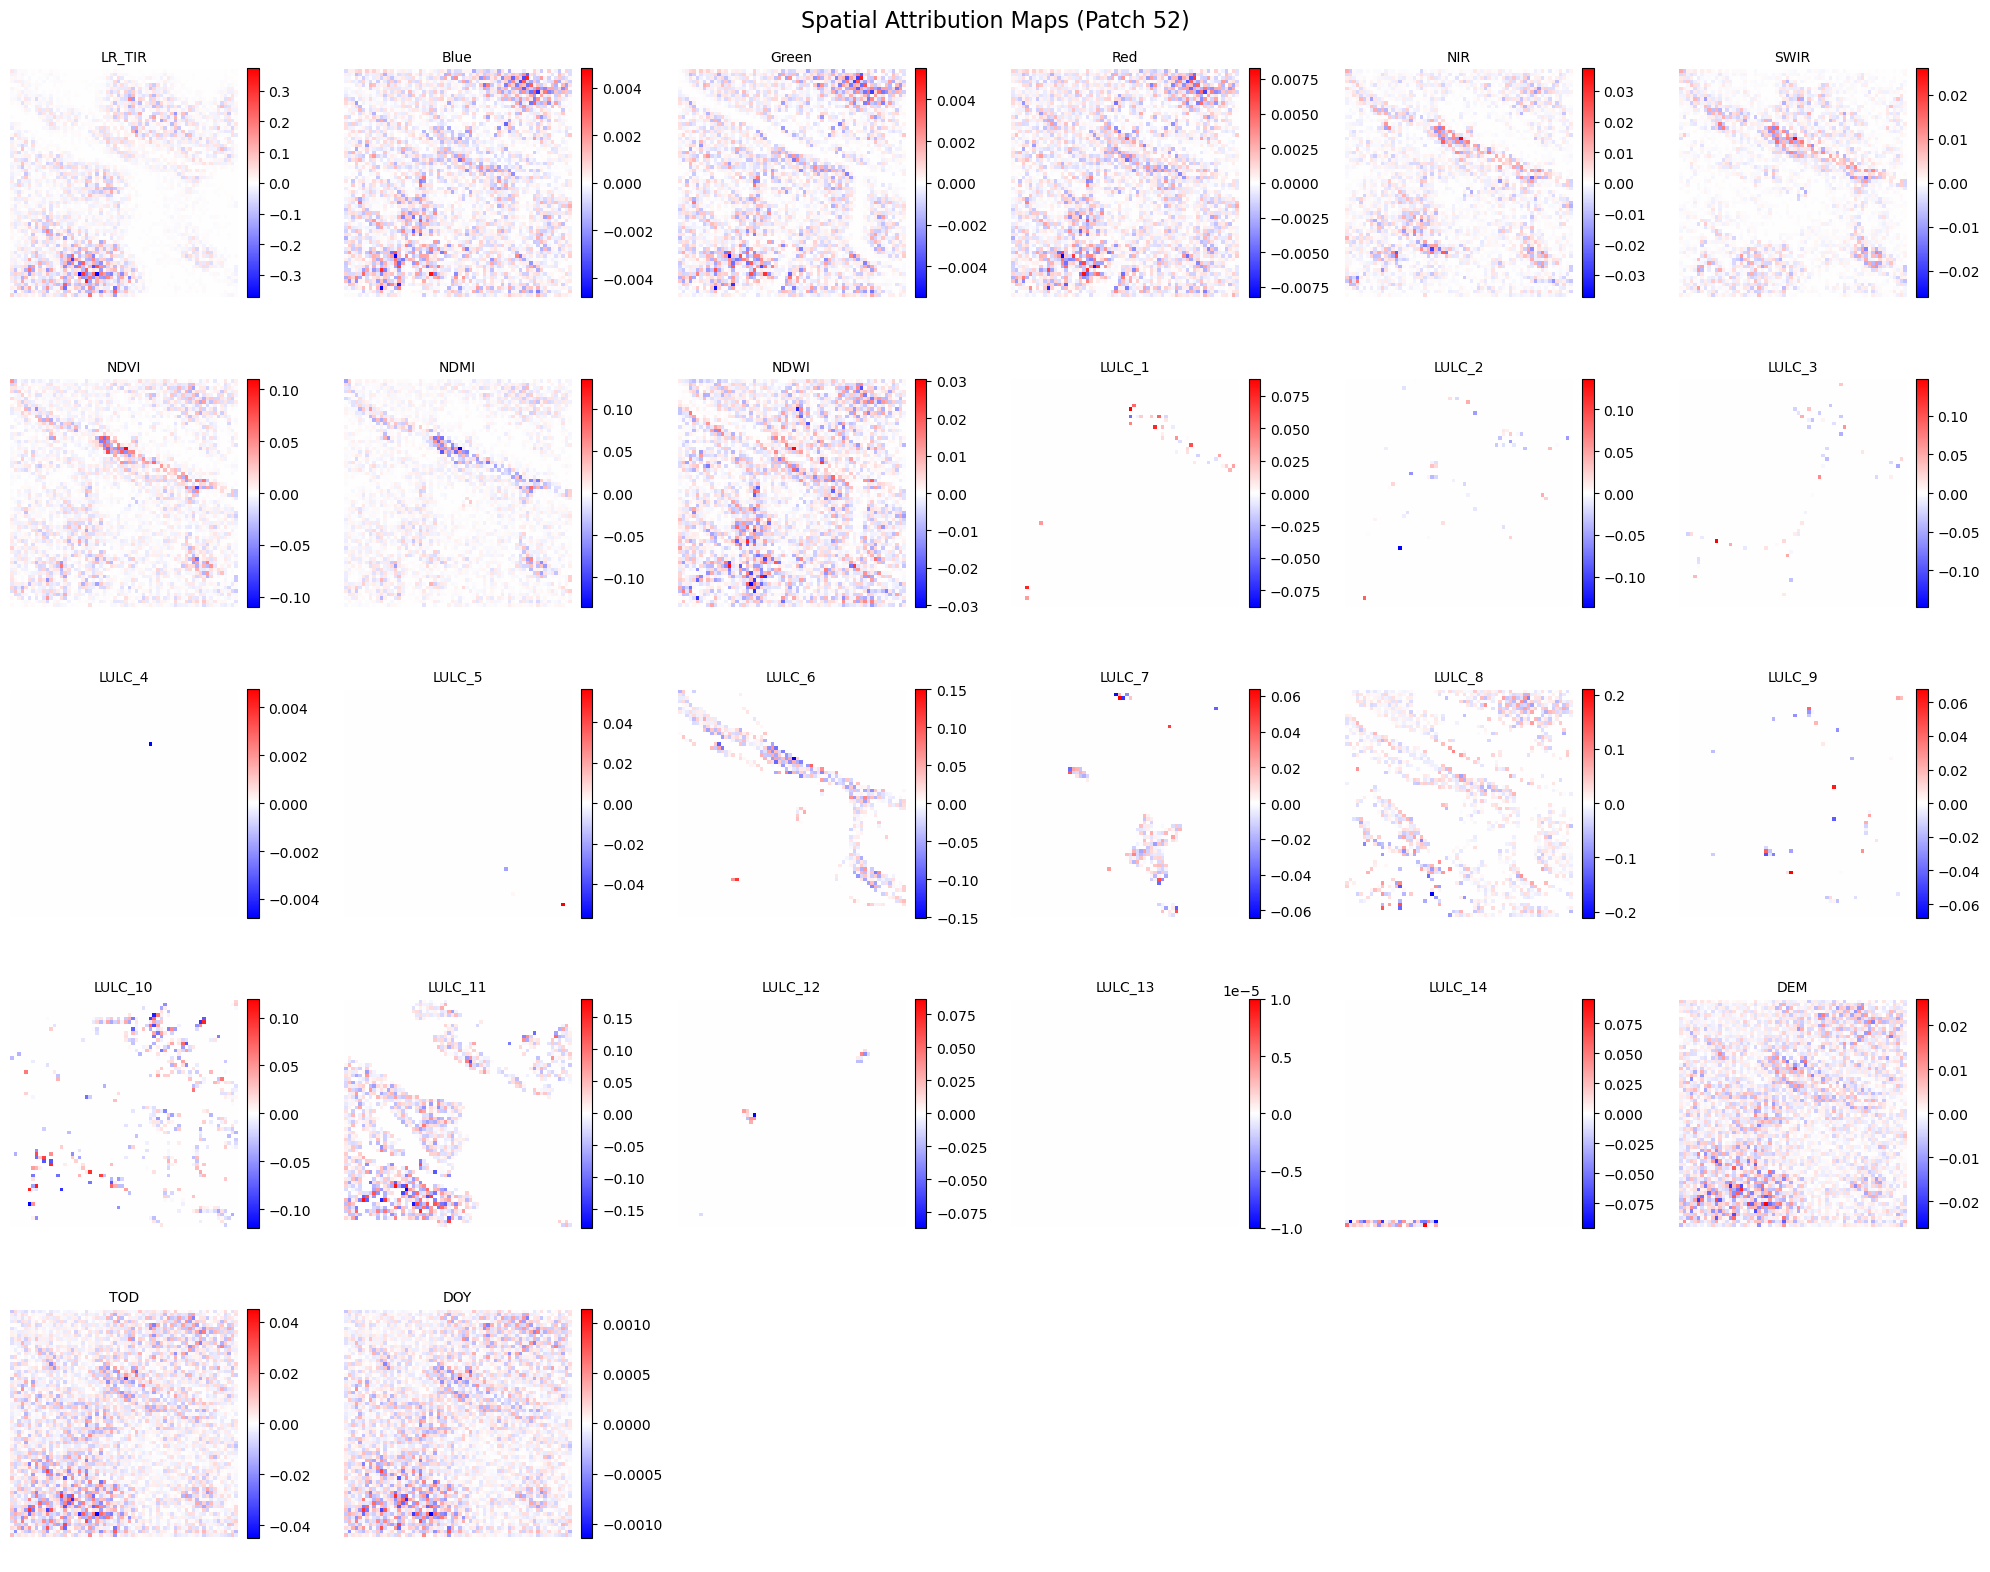

In [23]:
import numpy as np
# ── Step 1: Hybrid Mathematically Sound Baseline ───────────
print("Calculating baseline distributions...")
ch_sum, n_pixels = torch.zeros(26), 0
for batch in train_loader:
    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1)
    ch_sum += x.sum(dim=(0, 2, 3))
    n_pixels += x.shape[0] * x.shape[2] * x.shape[3]
global_means = (ch_sum / n_pixels).view(1, 26, 1, 1)

# Construct an intelligent baseline tensor
baseline_channel_means = torch.zeros(1, 26, 1, 1)
# Continuous variables: Use spatial mean reference
continuous_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 23] # LR_TIR, Spectral, Indices, DEM
baseline_channel_means[:, continuous_indices] = global_means[:, continuous_indices]
# Categorical/Discrete variables (LULC, Time metadata): Keep at 0 (absence of indicator)

torch.save(baseline_channel_means, "ig_baseline_hybrid.pt")
baseline_channel_means = baseline_channel_means.to(device)

# ── Step 2: Dynamic Captum Wrapper ──────────────────────────
# Captum expects a function signature that takes only the tensor being attributed as input.
class WrappedModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.seg_mid = None
        self.seg_hr = None
        self.valid_mask = None

    def set_batch_metadata(self, seg_mid, seg_hr, valid_mask):
        self.seg_mid = seg_mid
        self.seg_hr = seg_hr
        self.valid_mask = valid_mask

    def forward(self, x):
        gen_out = self.model.net_g(x, self.seg_mid, self.seg_hr) if self.model.use_spade else self.model.net_g(x, None, None)
        sr = self.model.out_head(gen_out)
        sr_phys = self.model.denormalize(sr) 
        
        # Guard against zero-element masks
        mask_sum = self.valid_mask.sum(dim=(1, 2, 3)).clamp(min=1)
        return (sr_phys * self.valid_mask).sum(dim=(1, 2, 3)) / mask_sum

wrapped_model = WrappedModel(model)
ig = IntegratedGradients(wrapped_model)

# ── Inside Step 3: Run Attributions and Average ─────────────────
channel_importance_total = torch.zeros(26)
deltas = []

print("Running attributions...")


for batch_idx, batch in enumerate(test_loader):
    batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1).float()
    x.requires_grad_(True)

    seg_mid = batch["aux_mid"][:, 8:22].float() if model.use_spade else None
    seg_hr  = batch["aux_hr"][:, 8:22].float()  if model.use_spade else None
    valid_mask = batch["hr_mask"][:, 0:1].float() 

    wrapped_model.set_batch_metadata(seg_mid, seg_hr, valid_mask)
    baseline_x = baseline_channel_means.expand_as(x)

    attr, delta = ig.attribute(
        x,
        baselines=baseline_x,
        n_steps=100,
        internal_batch_size=4,
        return_convergence_delta=True,
    )
    
    # Track the absolute magnitude of change forced by each covariate
    channel_importance_total += attr.abs().mean(dim=(0, 2, 3)).detach().cpu()
    deltas.append(delta.abs().mean().item())
    
    channel_names = [
            "LR_TIR",
            "Blue", "Green", "Red", "NIR", "SWIR",
            "NDVI", "NDMI", "NDWI",
            "LULC_1", "LULC_2", "LULC_3", "LULC_4",
            "LULC_5", "LULC_6", "LULC_7", "LULC_8",
            "LULC_9", "LULC_10", "LULC_11", "LULC_12",
            "LULC_13", "LULC_14",
            "DEM",
            "TOD", "DOY"
        ]
    
    # ── NEW: Extract and display spatial heatmaps for EVERY band ──
    if batch_idx in [5, 11, 52]:  # Target the first patch as your visual case study
        print(f"--> Generating spatial attribution maps for all 26 channels...")
        
        # We will plot them in a grid (e.g., 5 rows by 6 columns to fit all 26 cleanly)
        fig, axes = plt.subplots(5, 6, figsize=(20, 16))
        axes = axes.flatten() # Flatten the 2D grid of axes into a 1D array for easy looping
        
        for ch_idx in range(len(channel_names)):
            spatial_attr = attr[0, ch_idx].detach().cpu().numpy()
            
            # Calculate dynamic symmetric bounds so 0 is perfectly centered at white
            vmax = np.max(np.abs(spatial_attr))
            vmax = max(vmax, 1e-5) # Prevent division by zero if a channel is completely zero
            
            ax = axes[ch_idx]
            im = ax.imshow(spatial_attr, cmap="bwr", vmin=-vmax, vmax=vmax)
            
            ax.set_title(channel_names[ch_idx], fontsize=10)
            ax.axis('off') # Hide pixel coordinates for a cleaner presentation matrix
            
            # Add a small colorbar next to each individual subplot
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
        # Turn off any unused empty subplots at the end of the grid (since 5x6 = 30 slots, but we have 26 channels)
        for unused_idx in range(len(channel_names), len(axes)):
            axes[unused_idx].axis('off')
            
        plt.suptitle(f"Spatial Attribution Maps (Patch {batch_idx})", fontsize=16, y=0.98)
        plt.tight_layout()
        plt.show()  # Display the full grid in your notebook
        # plt.savefig(f"all_channels_spatial_attribution_patch_{batch_idx}.png", dpi=300) # Un-comment to save
        # plt.close()
        

In [6]:
# target_fname = "BRC_2022_b0_r512_c256.npy"
target_fname = "HAUT_2025_b0_r1792_c3840.npy"
# target_fname = "BRC_2023_b0_r1024_c1024.npy"

idx = test_ds.files.index(target_fname)
print(idx)

30


Index: 30
Filename: HAUT_2025_b0_r1792_c3840.npy


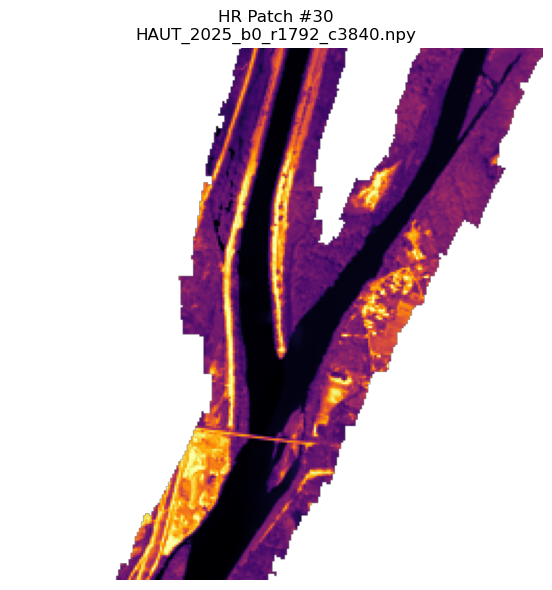

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PATCHES_DIR = Path("/share/home/e2406751/Superresolution-TIR/data/processed/patches")

# Get all HR patches in a consistent order
hr_files = sorted((PATCHES_DIR / "test" / "HR").glob("*.npy"))

idx = 30        

hr_path = hr_files[idx]

print(f"Index: {idx}")
print(f"Filename: {hr_path.name}")

# Load HR
hr = np.load(hr_path)

# Denormalize
hr_np = np.where(np.isfinite(hr), hr * HR_STD + HR_MEAN, np.nan)
valid = hr_np[np.isfinite(hr_np)]
vmin, vmax = np.percentile(valid, 1), np.percentile(valid, 99)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
plt.title(f"HR Patch #{idx}\n{hr_path.name}")
plt.axis("off")
# plt.colorbar(label="Temperature (°C)")
plt.tight_layout()
plt.show()

### Output attribution  
what does the model rely on to produce a temperature value

Calculating baseline distributions...


Running attributions...
--> Generating spatial attribution maps for all 26 channels...


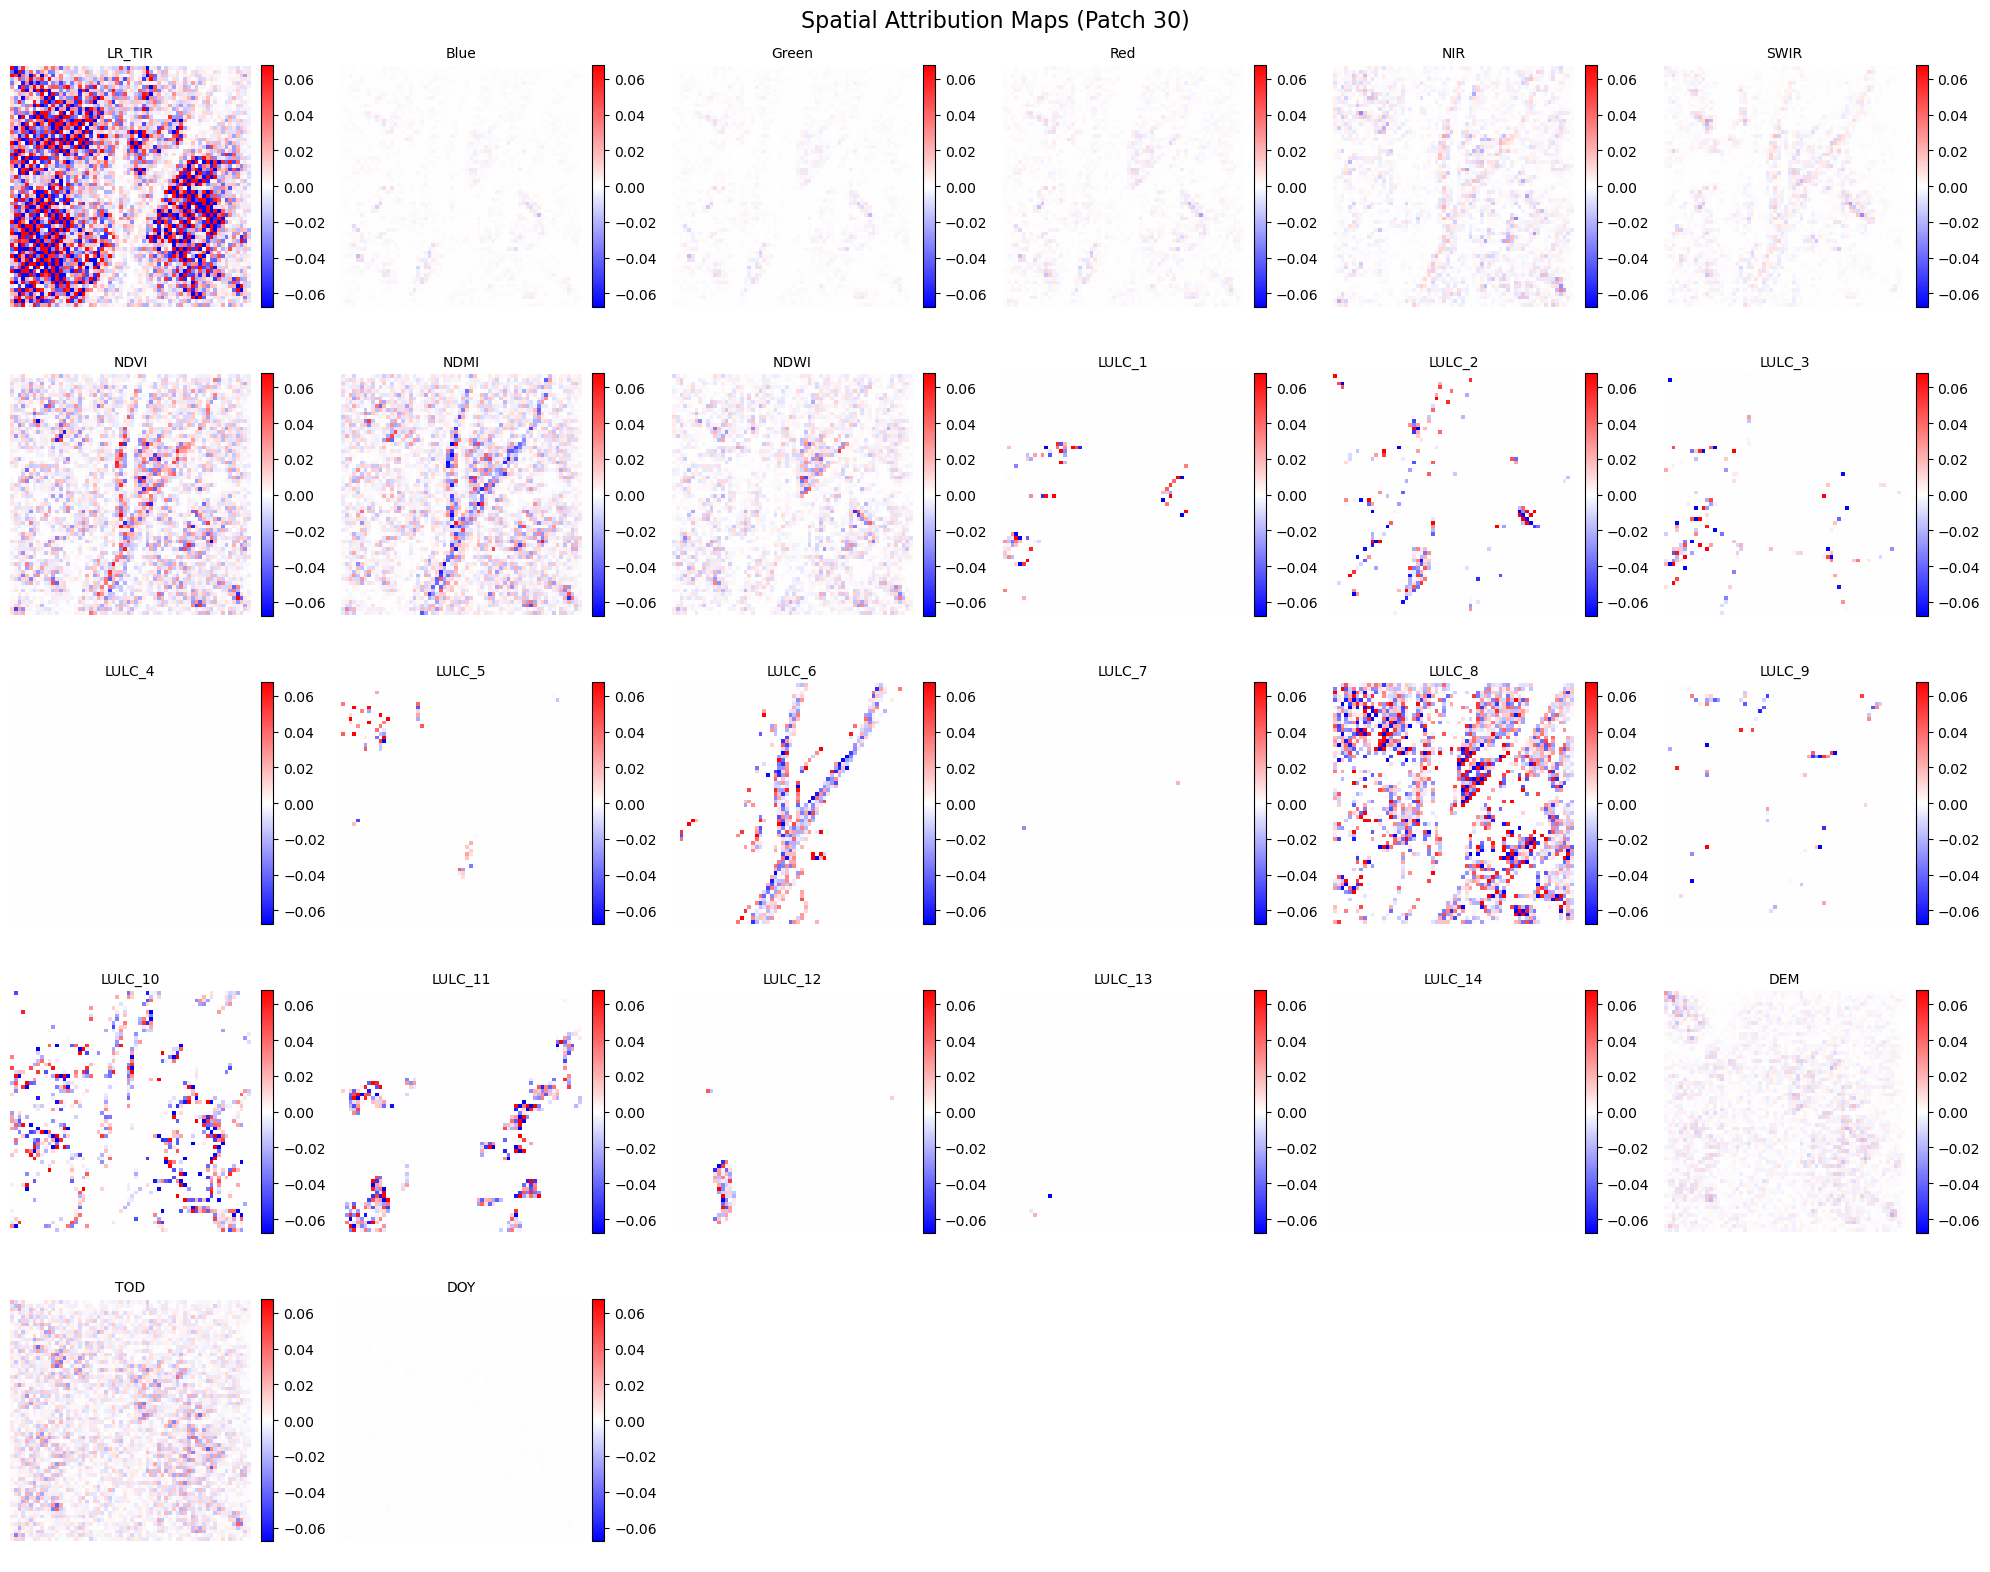

In [6]:
import numpy as np
# ── Step 1: Hybrid Mathematically Sound Baseline ───────────
print("Calculating baseline distributions...")
ch_sum, n_pixels = torch.zeros(26), 0
for batch in train_loader:
    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1)
    ch_sum += x.sum(dim=(0, 2, 3))
    n_pixels += x.shape[0] * x.shape[2] * x.shape[3]
global_means = (ch_sum / n_pixels).view(1, 26, 1, 1)

# Construct an intelligent baseline tensor
baseline_channel_means = torch.zeros(1, 26, 1, 1)
# Continuous variables: Use spatial mean reference
continuous_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 23] # LR_TIR, Spectral, Indices, DEM
baseline_channel_means[:, continuous_indices] = global_means[:, continuous_indices]
# Categorical/Discrete variables (LULC, Time metadata): Keep at 0 (absence of indicator)

torch.save(baseline_channel_means, "ig_baseline_hybrid.pt")
baseline_channel_means = baseline_channel_means.to(device)

# ── Step 2: Dynamic Captum Wrapper ──────────────────────────
# Captum expects a function signature that takes only the tensor being attributed as input.
class WrappedModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.seg_mid = None
        self.seg_hr = None
        self.valid_mask = None

    def set_batch_metadata(self, seg_mid, seg_hr, valid_mask):
        self.seg_mid = seg_mid
        self.seg_hr = seg_hr
        self.valid_mask = valid_mask

    def forward(self, x):
        gen_out = self.model.net_g(x, self.seg_mid, self.seg_hr) if self.model.use_spade else self.model.net_g(x, None, None)
        sr = self.model.out_head(gen_out)
        sr_phys = self.model.denormalize(sr) 
        
        # Guard against zero-element masks
        mask_sum = self.valid_mask.sum(dim=(1, 2, 3)).clamp(min=1)
        return (sr_phys * self.valid_mask).sum(dim=(1, 2, 3)) / mask_sum

wrapped_model = WrappedModel(model)
ig = IntegratedGradients(wrapped_model)

# ── Inside Step 3: Run Attributions and Average ─────────────────
channel_importance_total = torch.zeros(26)
deltas = []

print("Running attributions...")


for batch_idx, batch in enumerate(test_loader):
    batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1).float()
    x.requires_grad_(True)

    seg_mid = batch["aux_mid"][:, 8:22].float() if model.use_spade else None
    seg_hr  = batch["aux_hr"][:, 8:22].float()  if model.use_spade else None
    valid_mask = batch["hr_mask"][:, 0:1].float() 

    wrapped_model.set_batch_metadata(seg_mid, seg_hr, valid_mask)
    baseline_x = baseline_channel_means.expand_as(x)

    attr, delta = ig.attribute(
        x,
        baselines=baseline_x,
        n_steps=100,
        internal_batch_size=4,
        return_convergence_delta=True,
    )
    
    # Track the absolute magnitude of change forced by each covariate
    channel_importance_total += attr.abs().mean(dim=(0, 2, 3)).detach().cpu()
    deltas.append(delta.abs().mean().item())
    
    channel_names = [
            "LR_TIR",
            "Blue", "Green", "Red", "NIR", "SWIR",
            "NDVI", "NDMI", "NDWI",
            "LULC_1", "LULC_2", "LULC_3", "LULC_4",
            "LULC_5", "LULC_6", "LULC_7", "LULC_8",
            "LULC_9", "LULC_10", "LULC_11", "LULC_12",
            "LULC_13", "LULC_14",
            "DEM",
            "TOD", "DOY"
        ]
    
    # # ── Extract and display spatial heatmaps for EVERY band ──
    # if batch_idx == 30:
    #     print(f"--> Generating spatial attribution maps for all 26 channels (Patch {batch_idx})...")
        
    #     # 5x6 grid provides 30 slots to comfortably accommodate all 26 channels
    #     fig, axes = plt.subplots(5, 6, figsize=(20, 16), dpi=300)
    #     axes = axes.flatten()  # Flatten 2D grid to 1D for straightforward iteration
        
    #     for ch_idx, ch_name in enumerate(channel_names):
    #         spatial_attr = attr[0, ch_idx].detach().cpu().numpy()
            
    #         # Calculate dynamic symmetric bounds centered around 0
    #         vmax = max(np.max(np.abs(spatial_attr)), 1e-5)
            
    #         ax = axes[ch_idx]
    #         im = ax.imshow(spatial_attr, cmap="bwr", vmin=-vmax, vmax=vmax)
            
    #         ax.set_title(ch_name, fontsize=10, fontweight="bold")
    #         ax.axis("off")  # Hide axis ticks for a clean matrix look
            
    #         # Individual colorbar matching the height of each subplot
    #         fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
    #     # Turn off the 4 remaining unused subplots (slots 26 through 29)
    #     for unused_ax in axes[len(channel_names):]:
    #         unused_ax.axis("off")
            
    #     plt.suptitle(f"Spatial Attribution Maps — Patch {batch_idx}", fontsize=16, fontweight="bold", y=0.98)
    #     plt.tight_layout()
        
    #     # Save high-res figure and display
    #     plt.savefig(f"spatial_attribution.png", dpi=600, bbox_inches="tight")
    #     plt.show()
    #     # plt.close()  

    # ── NEW: Extract and display spatial heatmaps for EVERY band ──
    if batch_idx  == 30:  # Target the first patch as your visual case study
        print(f"--> Generating spatial attribution maps for all 26 channels...")
        
        # We will plot them in a grid (e.g., 5 rows by 6 columns to fit all 26 cleanly)
        fig, axes = plt.subplots(5, 6, figsize=(20, 16))
        axes = axes.flatten() # Flatten the 2D grid of axes into a 1D array for easy looping
        
        all_attr = attr[0].detach().cpu().numpy()          # [26, 64, 64]
        # global_vmax = np.max(np.abs(all_attr))
        # global_vmax = max(global_vmax, 1e-5)
        vmax = np.percentile(np.abs(all_attr), 99)

        for ch_idx in range(len(channel_names)):
            spatial_attr = all_attr[ch_idx]
            ax = axes[ch_idx]
            im = ax.imshow(spatial_attr, cmap="bwr", vmin=-vmax, vmax=vmax)
            ax.set_title(channel_names[ch_idx], fontsize=10)
            ax.axis('off')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
        # Turn off any unused empty subplots at the end of the grid (since 5x6 = 30 slots, but we have 26 channels)
        for unused_idx in range(len(channel_names), len(axes)):
            axes[unused_idx].axis('off')
            
        plt.suptitle(f"Spatial Attribution Maps (Patch {batch_idx})", fontsize=16, y=0.98)
        plt.tight_layout()
        plt.savefig(f"spatial_attribution.png", dpi=600, bbox_inches="tight")
        plt.show()  
        

In [ ]:
from captum.attr import FeatureAblation

fa = FeatureAblation(wrapped_model)

# group every pixel of channel c into one ablatable unit
feature_mask = torch.arange(26).view(1, 26, 1, 1).expand_as(x).to(device)

attr_fa = fa.attribute(
    x,
    baselines=baseline_x,
    feature_mask=feature_mask,
)
channel_importance_fa = attr_fa.abs().mean(dim=(0, 2, 3))  # one scalar per channel, exact ablation effect

### Error attribution   
what does the model need in order to be correct 

In [5]:
import numpy as np
# ── Step 1: Hybrid Mathematically Sound Baseline ───────────
print("Calculating baseline distributions...")
ch_sum, n_pixels = torch.zeros(26), 0
for batch in train_loader:
    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1)
    ch_sum += x.sum(dim=(0, 2, 3))
    n_pixels += x.shape[0] * x.shape[2] * x.shape[3]
global_means = (ch_sum / n_pixels).view(1, 26, 1, 1)

# Construct an intelligent baseline tensor
baseline_channel_means = torch.zeros(1, 26, 1, 1)
# Continuous variables: Use spatial mean reference
continuous_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 23] # LR_TIR, Spectral, Indices, DEM
baseline_channel_means[:, continuous_indices] = global_means[:, continuous_indices]
# Categorical/Discrete variables (LULC, Time metadata): Keep at 0 (absence of indicator)

torch.save(baseline_channel_means, "ig_baseline_hybrid.pt")
baseline_channel_means = baseline_channel_means.to(device)

class WrappedModelError(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.seg_mid = None
        self.seg_hr = None
        self.valid_mask = None
        self.hr_gt = None  # add ground truth

    def set_batch_metadata(self, seg_mid, seg_hr, valid_mask, hr_gt):
        self.seg_mid = seg_mid
        self.seg_hr = seg_hr
        self.valid_mask = valid_mask
        self.hr_gt = hr_gt

    def forward(self, x):
        gen_out = self.model.net_g(x, self.seg_mid, self.seg_hr) if self.model.use_spade else self.model.net_g(x, None, None)
        sr = self.model.out_head(gen_out)
        sr_phys = self.model.denormalize(sr)

        mask_sum = self.valid_mask.sum(dim=(1, 2, 3)).clamp(min=1)
        # negative masked L1 error — IG wants a scalar target;
        # negating means "positive attribution = pushes error down"
        err = (sr_phys - self.hr_gt).abs() * self.valid_mask
        return -(err.sum(dim=(1, 2, 3)) / mask_sum)

wrapped_model = WrappedModel(model)
ig = IntegratedGradients(wrapped_model)

# ── Inside Step 3: Run Attributions and Average ─────────────────
channel_importance_total = torch.zeros(26)
deltas = []

print("Running attributions...")


for batch_idx, batch in enumerate(test_loader):
    batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

    x = torch.cat([batch["lr"], batch["aux_lr"], batch["time_channels"]], dim=1).float()
    x.requires_grad_(True)

    seg_mid = batch["aux_mid"][:, 8:22].float() if model.use_spade else None
    seg_hr  = batch["aux_hr"][:, 8:22].float()  if model.use_spade else None
    valid_mask = batch["hr_mask"][:, 0:1].float() 

    wrapped_model.set_batch_metadata(seg_mid, seg_hr, valid_mask)
    baseline_x = baseline_channel_means.expand_as(x)

    attr, delta = ig.attribute(
        x,
        baselines=baseline_x,
        n_steps=100,
        internal_batch_size=4,
        return_convergence_delta=True,
    )
    
    # Track the absolute magnitude of change forced by each covariate
    channel_importance_total += attr.abs().mean(dim=(0, 2, 3)).detach().cpu()
    deltas.append(delta.abs().mean().item())
    
    channel_names = [
            "LR_TIR",
            "Blue", "Green", "Red", "NIR", "SWIR",
            "NDVI", "NDMI", "NDWI",
            "LULC_1", "LULC_2", "LULC_3", "LULC_4",
            "LULC_5", "LULC_6", "LULC_7", "LULC_8",
            "LULC_9", "LULC_10", "LULC_11", "LULC_12",
            "LULC_13", "LULC_14",
            "DEM",
            "TOD", "DOY"
        ]
    
    # # ── NEW: Extract and display spatial heatmaps for EVERY band ──
    # if batch_idx in [5, 11, 52]:  # Target the first patch as your visual case study
    #     print(f"--> Generating spatial attribution maps for all 26 channels...")
        
    #     # We will plot them in a grid (e.g., 5 rows by 6 columns to fit all 26 cleanly)
    #     fig, axes = plt.subplots(5, 6, figsize=(20, 16))
    #     axes = axes.flatten() # Flatten the 2D grid of axes into a 1D array for easy looping
        
    #     all_attr = attr[0].detach().cpu().numpy()          # [26, 64, 64]
    #     # global_vmax = np.max(np.abs(all_attr))
    #     # global_vmax = max(global_vmax, 1e-5)
    #     vmax = np.percentile(np.abs(all_attr), 99)

    #     for ch_idx in range(len(channel_names)):
    #         spatial_attr = all_attr[ch_idx]
    #         ax = axes[ch_idx]
    #         im = ax.imshow(spatial_attr, cmap="bwr", vmin=-vmax, vmax=vmax)
    #         ax.set_title(channel_names[ch_idx], fontsize=10)
    #         ax.axis('off')
    #         fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
    #     # Turn off any unused empty subplots at the end of the grid (since 5x6 = 30 slots, but we have 26 channels)
    #     for unused_idx in range(len(channel_names), len(axes)):
    #         axes[unused_idx].axis('off')
            
    #     plt.suptitle(f"Spatial Attribution Maps (Patch {batch_idx})", fontsize=16, y=0.98)
    #     plt.tight_layout()
    #     plt.show()  
    
    # ── Extract and display spatial heatmaps for EVERY band ──
    if batch_idx == 30:
        print(f"--> Generating spatial attribution maps for all 26 channels (Patch {batch_idx})...")
        
        # 5x6 grid provides 30 slots to comfortably accommodate all 26 channels
        fig, axes = plt.subplots(5, 6, figsize=(20, 16), dpi=300)
        axes = axes.flatten()  # Flatten 2D grid to 1D for straightforward iteration
        
        for ch_idx, ch_name in enumerate(channel_names):
            spatial_attr = attr[0, ch_idx].detach().cpu().numpy()
            
            # Calculate dynamic symmetric bounds centered around 0
            vmax = max(np.max(np.abs(spatial_attr)), 1e-5)
            
            ax = axes[ch_idx]
            im = ax.imshow(spatial_attr, cmap="bwr", vmin=-vmax, vmax=vmax)
            
            ax.set_title(ch_name, fontsize=10, fontweight="bold")
            ax.axis("off")  # Hide axis ticks for a clean matrix look
            
            # Individual colorbar matching the height of each subplot
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
        # Turn off the 4 remaining unused subplots (slots 26 through 29)
        for unused_ax in axes[len(channel_names):]:
            unused_ax.axis("off")
            
        plt.suptitle(f"Spatial Attribution Maps — Patch {batch_idx}", fontsize=16, fontweight="bold", y=0.98)
        plt.tight_layout()
        
        # Save high-res figure and display
        plt.savefig(f"spatial_attribution.png", dpi=600, bbox_inches="tight")
        plt.show()
        # plt.close()  

Calculating baseline distributions...


NameError: name 'WrappedModel' is not defined